# Probability-based hybrid nearest neighbor model plot generation

## Imports

In [9]:
%load_ext autoreload
%load_ext rpy2.ipython
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import auc
import pandas as pd
from pandas.io.parsers import read_csv
from hybrids import max_pareto_front
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [10]:
%%R
# The pnnclass from https://github.com/paulocmarquesf/pnnclass/tree/master crashes with segmentation fault.
# You need to download the source code, change the line 17 of the R/pnnclass.R into
# "if (opt$par == 0 && r != 1) break" and install that using install.packages.
library(pnnclass)
library(foreach)
library(doParallel)
library(dplyr)
library(pracma)

## Data reading

In [11]:
blackbox = 'rf'  # Random forest
# blackbox = 'ab'  # AdaBoosted decision trees
# blackbox = 'xg'  # XGboost (gbtree)

In [12]:
path = './datasets/census/'; name = 'census'

# path = './datasets/coupon/'; name = 'coupon'

# path = './datasets/stop&frisk/'; name = 'stop-and-frisk'

In [13]:
normalize = True

# read data
Xtrain = read_csv(path + 'train.csv',header = 0, sep = ',')
Xtest = read_csv(path + 'test.csv',header = 0, sep = ',')
bbm = read_csv(path + blackbox + '_ybtrain.csv',header = 0,sep = ',')
Ybtrain = np.array(bbm['Yb'])
bbm = read_csv(path + blackbox + '_ybtest.csv',header = 0,sep = ',')
Ybtest = np.array(bbm['Yb'])

ntrain = Xtrain.shape[0]
df = pd.concat([Xtrain, Xtest])
# Seperate Y (answers) from dataframe
Y = np.array(df['Y'])
# df.drop(['Y'], axis = 1, inplace = True) 
numericals = [col for col in Xtrain.columns if Xtrain[col].dtype in [int, float] and (~Xtrain[col].isin([0, 1])).any()]

if normalize:
    # Normalize data
    df = df.astype({col: float for col in numericals})
    mean = Xtrain.loc[:, numericals].mean(axis=0)
    std = Xtrain.loc[:, numericals].std(axis=0) + 1e-8
    df.loc[:, numericals] = (df.loc[:, numericals] - mean) / std


ntrain = Xtrain.shape[0]
Ytrain = Y[:ntrain]
Ytest = Y[ntrain:]
Xtrain = df[:ntrain]
Xtest = df[ntrain:]


## Generate results with probabilisty based hybrid nearest neighbors

In [14]:
dftrain = df[:1000]
dfvalidate = df[1000:2000]
dftest = df[ntrain:]

Forward sequential feature selection

In [ ]:
%%R -i dftrain -i dftest -i dfvalidate -o history -i Ybtest
Ybtest <-as.integer(Ybtest)
# Convert column names to something R can manage (since education-num == "education minus num" by R formula)
colnames(dftrain) <- make.names(colnames(dftrain), unique = TRUE)
colnames(dftest)  <- make.names(colnames(dftest), unique = TRUE)
colnames(dfvalidate)  <- make.names(colnames(dfvalidate), unique = TRUE)
# Categorical (0 and 1) columns are considered integer, convert them to numeric so that pnnclass doesn't complain
x_cols <- setdiff(colnames(dftrain), "Y")
dftrain[x_cols] <- lapply(dftrain[x_cols], as.numeric)
dftest[x_cols]  <- lapply(dftest[x_cols],  as.numeric)
dfvalidate[x_cols]  <- lapply(dfvalidate[x_cols],  as.numeric)

# for each subset of features during greedy search, parallelized using foreach %dopar%
cl <- makeCluster(parallel::detectCores() - 1, outfile="") 
registerDoParallel(cl)

# Function to combine each foreach return value
keep_best <- function(acc, new_val) {
    if (
        mean(acc$y_hat == dfvalidate[["Y"]])
        < mean(new_val$y_hat == dfvalidate[["Y"]])
    ) {
        acc <- new_val
    }
    acc
}

all_features <- setdiff(colnames(dftrain), "Y")
selected <- character(0)
remaining <- all_features
max_features <- length(all_features)
history <- data.frame()

for (step in seq_len(max_features)) {
    # parallel compute best feature to add
    best_res <- foreach(
        feature = remaining,
        .combine = "keep_best",
        .packages = c("pnnclass"),
        .errorhandling = "remove"
    ) %dopar% {
        print(sprintf("feature %d/%d, trying %s", step, max_features, feature))
        trial_features <- c(selected, feature)
        # Formula about predicting Y using currently selected featuers
        fml <- as.formula(
        paste("Y", "~", paste(trial_features, collapse = " + "))
        )
        # Use pnnclass: train using first 1000 datapoints and test by predicting next 1000 datapoints
        model <- pnnclass(fml, data = dftrain)
        pred <- predict(model, newdata = dfvalidate)
        ret_list <- list(y_hat = matrix(as.integer(pred$y_hat)),
                        added_feature = feature,
                        model = model)
        ret_list
    }
    # Select best performed feature in terms of prediction score of dfvalidate
    selected <- c(selected, best_res$added_feature)
    remaining <- setdiff(remaining, best_res$added_feature)

    pred <- predict(best_res$model, newdata = dftest)
    print(
        sprintf(
        "added feature: %s, accuracy: %f",
        best_res$added_feature,
        mean(pred$y_hat == dftest[["Y"]])
        )
    )

    test_num <- length(dftest[["Y"]])
    # For every feature subset, experiment with resulting probability based hybrid nearest neighbors
    for (offload_thrs in c(linspace(0, 0.5, 20), 0.6)) {
        # If probability of one class is too close to 0.5 (determined by offload_thrs) then defer to black-box
        hyb_yhat <- pred$y_hat
        mask <- abs(pred$prob[, 1] - 0.5) < offload_thrs
        covered_amount <- test_num - sum(mask)
        hyb_yhat[mask] <- Ybtest[mask]

        history <- bind_rows(
            history,
            data.frame(
                offload_thrs = offload_thrs,
                transparency = covered_amount / test_num,
                accuracy = mean(hyb_yhat == dftest[["Y"]]),
                features_used = step,
                k_nearest = best_res$model$k_hat
            )
        )
    }
}

stopCluster(cl)



## Plot predictions using minimized results

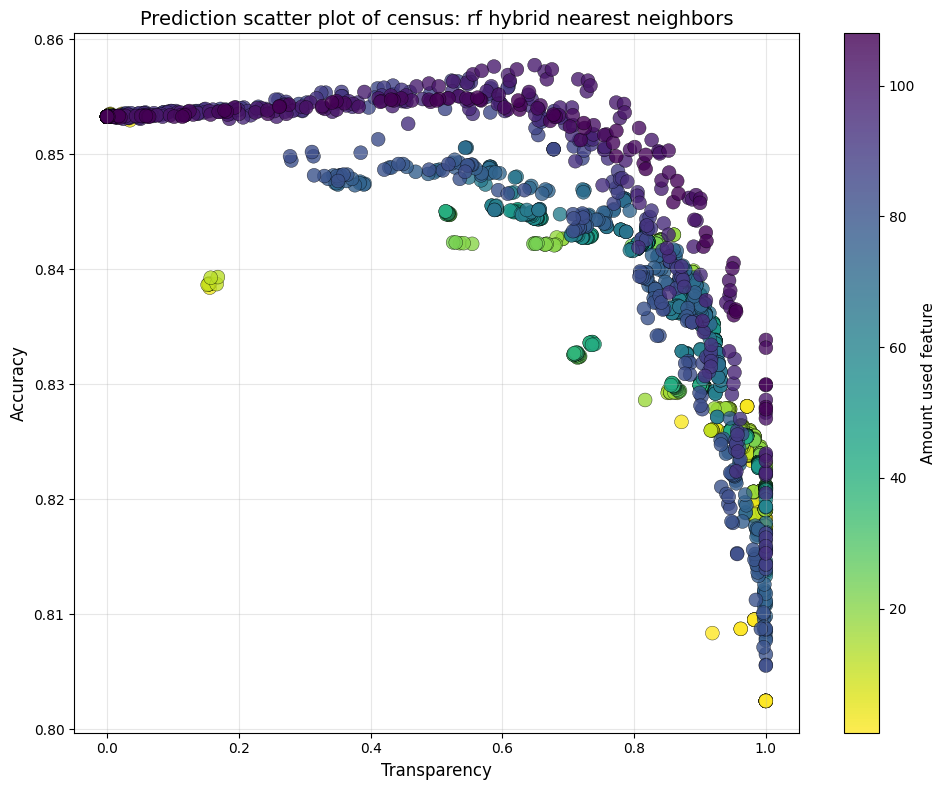

In [24]:
# Save as csv
results_df = pd.DataFrame(history)
# results_df.to_csv(path + f"{name}_{blackbox}_hybpnn_results.csv", index=False)

# Create the plot
plt.figure(figsize=(10, 8))

transparency_vals = results_df['transparency']
accuracy_vals = results_df['accuracy']
features_vals = results_df['features_used']

scatter = plt.scatter(
    transparency_vals,
    accuracy_vals,
    c=features_vals,
    cmap='viridis_r',
    s=100,
    alpha=0.8,
    edgecolors='black',
    linewidths=0.3,
 )

cbar = plt.colorbar(scatter)
cbar.set_label('Amount used feature', fontsize=11)

plt.xlabel('Transparency', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title(f'Prediction scatter plot of {name}: {blackbox} hybrid nearest neighbors', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim(-0.05, 1.05)
plt.tight_layout()
# plt.savefig(path + f'{name}_{blackbox}_hybpnn_scatter.svg')
plt.show()

#### Pareto front with unlimited features

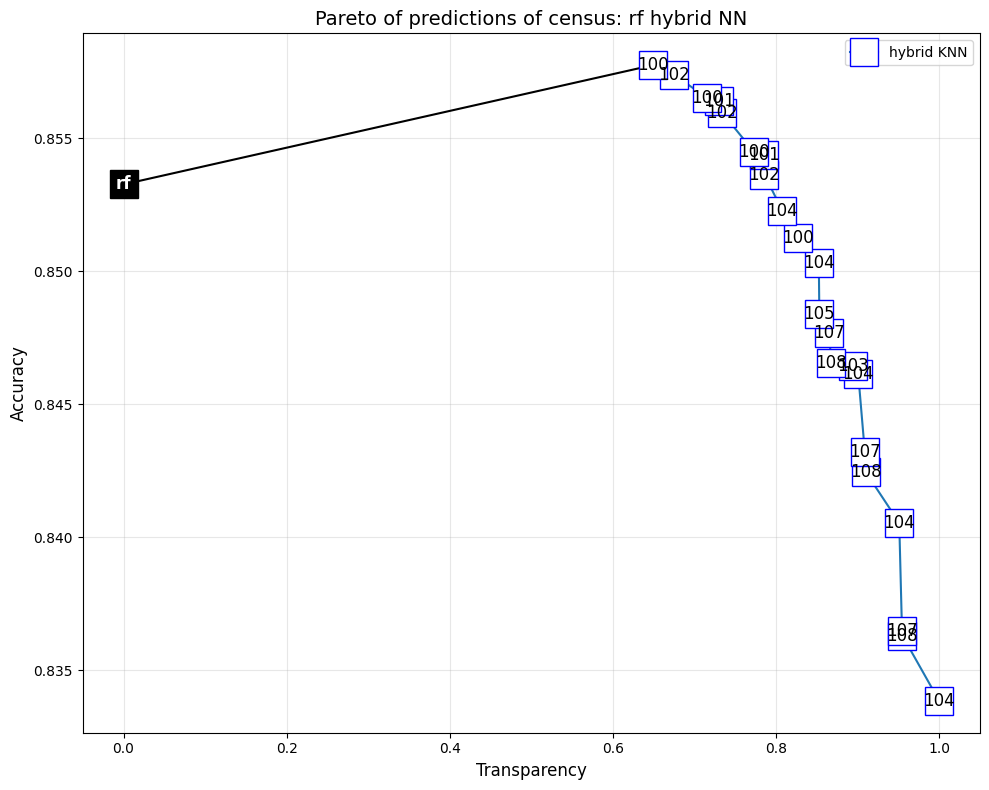

In [25]:
maxpf_df = max_pareto_front(results_df, "transparency", "accuracy")
yb_accuracy = (Ybtest == Ytest).mean()
# Create the plot
plt.figure(figsize=(10, 8))


axes = plt.gca()
plt.plot([0, maxpf_df.iloc[-1]["transparency"]], [yb_accuracy, maxpf_df.iloc[-1]["accuracy"]], color="black")
axes = maxpf_df.plot(x="transparency", y="accuracy", ax=axes, marker='s', markersize=20, markerfacecolor='white', markeredgecolor='blue', label="hybrid KNN")
plt.plot(0, yb_accuracy, 's', markersize=20, markerfacecolor='black', markeredgecolor='black')
for i, row in maxpf_df.iterrows():
    plt.text(row["transparency"], row["accuracy"], int(row["features_used"]), 
             ha='center', 
             va='center', 
             fontsize=12, 
             color='black', 
             )
plt.text(0, yb_accuracy, blackbox,
         ha='center', 
         va='center', 
         fontsize=12, 
         fontweight="bold",
         color="white")
plt.xlabel('Transparency', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title(f'Pareto of predictions of {name}: {blackbox} hybrid NN', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim(-0.05, 1.05)
plt.tight_layout()
# plt.savefig(path + f'{name}_{blackbox}_hybpnn_pareto.svg')
plt.show()

#### Pareto front with dataframe filtered by amount of features used

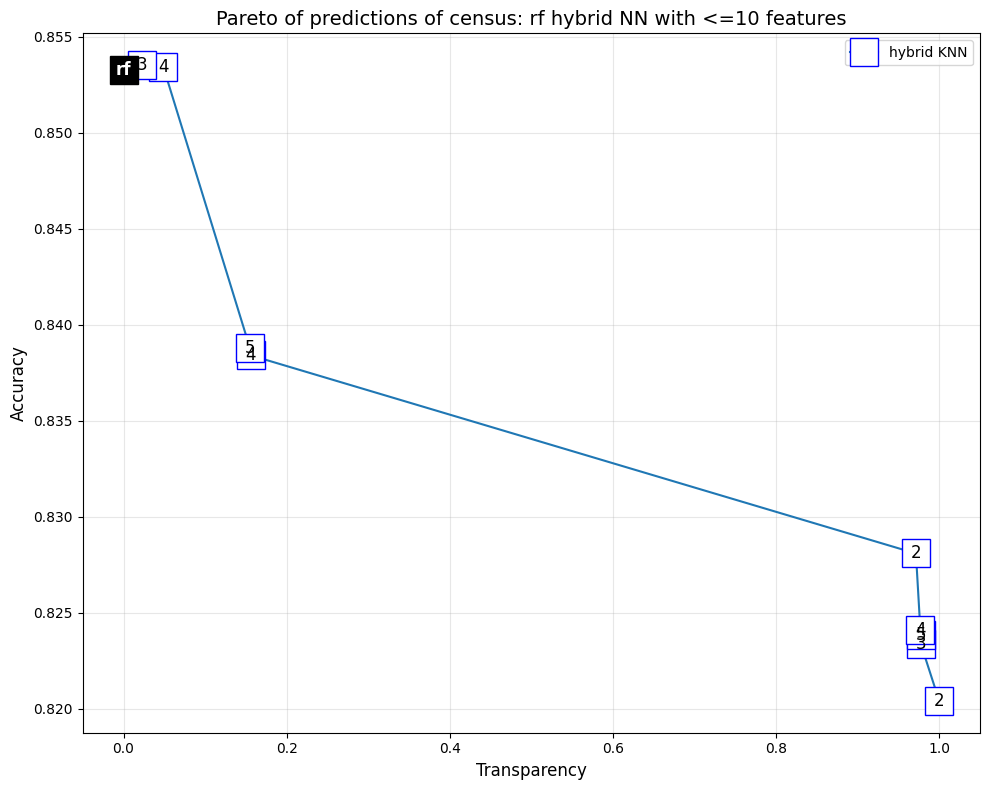

In [26]:
le_feature = 10
maxpf_df = max_pareto_front(results_df[results_df["features_used"] <= le_feature], "transparency", "accuracy")
yb_accuracy = (Ybtest == Ytest).mean()
# Create the plot
plt.figure(figsize=(10, 8))


axes = plt.gca()
plt.plot([0, maxpf_df.iloc[-1]["transparency"]], [yb_accuracy, maxpf_df.iloc[-1]["accuracy"]], color="black")
axes = maxpf_df.plot(x="transparency", y="accuracy", ax=axes, marker='s', markersize=20, markerfacecolor='white', markeredgecolor='blue', label="hybrid KNN")
plt.plot(0, yb_accuracy, 's', markersize=20, markerfacecolor='black', markeredgecolor='black')
for i, row in maxpf_df.iterrows():
    plt.text(row["transparency"], row["accuracy"], int(row["features_used"]), 
             ha='center', 
             va='center', 
             fontsize=12, 
             color='black', 
             )
plt.text(0, yb_accuracy, blackbox,
         ha='center', 
         va='center', 
         fontsize=12, 
         fontweight="bold",
         color="white")
plt.xlabel('Transparency', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title(f'Pareto of predictions of {name}: {blackbox} hybrid NN with <={le_feature} features', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim(-0.05, 1.05)
plt.tight_layout()
# plt.savefig(path + f'{name}_{blackbox}_hybpnn_pareto_featurefilteredby{le_feature}.svg')
plt.show()

## Colerful AUTAC (area under the accuracy-transparency trade-off curve) bar

AUTAC with feature$\leq2$: 0.8402039161883146
AUTAC with feature$\leq10$: 0.8352972036797347
AUTAC with feature$\leq20$: 0.8464837874111757
AUTAC with feature$\leq30$: 0.845161141585781
AUTAC with feature$\leq40$: 0.8451517856005359
AUTAC with feature$\leq50$: 0.8460632641687221
AUTAC with feature$\leq60$: 0.8459512526534358
AUTAC with feature$\leq70$: 0.847807283952164
AUTAC with feature$\leq80$: 0.8477215427607704
AUTAC with feature$\leq90$: 0.851624133584365
AUTAC with feature$\leq100$: 0.8540244493247225
AUTAC with No restriction: 0.8547353853672413


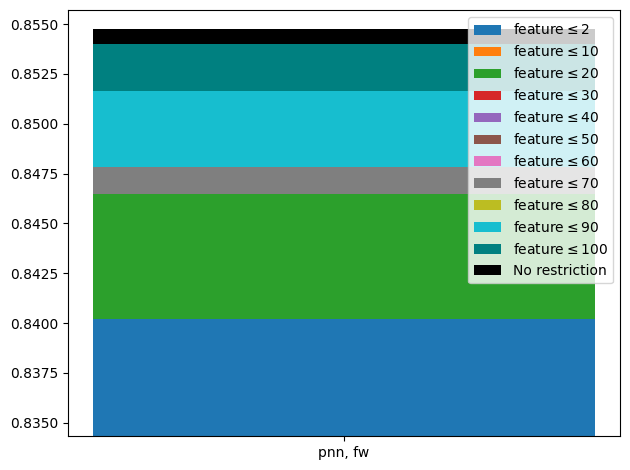

In [27]:
def get_autacs(th):
    pareto_df = max_pareto_front(
        (results_df[results_df["features_used"] <= th]) if th != None else results_df, "transparency", "accuracy"
    ).sort_values("transparency", ascending=False, ignore_index=True)
    pareto_df.loc[len(pareto_df)] = {
        "offload_thrs": 0,
        "transparency": 0,
        "accuracy": pareto_df["accuracy"].iloc[-1],
        "features_used": pareto_df["features_used"].iloc[-1],
    }
    return auc(pareto_df["transparency"], pareto_df["accuracy"])

ax = plt.gca()


feature_filter_list = [2] + list(range(10, 101, 10)) + [None]
autacs = [get_autacs(th) for th in feature_filter_list]
labels = [f"feature$\\leq{th}$" if th is not None else "No restriction" for th in feature_filter_list]
colors = [f"C{i}" for i in range(10)] + ["teal", "black"]

au_max = max(autacs)
au_min = min(autacs)
margin = (au_max - au_min) * 0.05
range_min = au_min - margin
range_max = au_max + margin

for idx, autac in enumerate(autacs):
    print(f"AUTAC with {labels[idx]}:",autac)
    ax.bar(
        [f"pnn, fw"], 
        autac, label=labels[idx], 
        color=colors[idx], 
        zorder=-idx
        )
ax.set_ylim(range_min, range_max)
plt.tight_layout()
plt.legend()
plt.show()